# Problem Understanding

Retail businesses deal with customers having different purchasing patterns across product categories such as Fresh, Milk, Grocery, Frozen, Detergents, and Delicatessen.

The objective of this project is to use **Hierarchical Clustering** (Unsupervised Learning) to group customers based on similar product spending behaviour.

This helps retailers in:
- Customer segmentation
- Targeted marketing
- Inventory optimization
- Strategic decision-making

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [71]:
# Load wholesale customers dataset
df = pd.read_csv("C:/Users/MSK/Documents/DS_Project/Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### Dataset Description

- **Fresh**: Spending on fresh products
- **Milk**: Spending on milk products
- **Grocery**: Spending on grocery items
- **Frozen**: Spending on frozen food
- **Detergents_Paper**: Spending on cleaning products
- **Delicatessen**: Spending on ready-to-eat items
- **Channel**: Customer type
- **Region**: Geographic region

## Data Understanding

Explore dataset variables, structure, and initial summary statistics.

In [72]:
# Understand dataset structure and statistics
print(df.shape)
df.info()
df.describe().T

(440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


## Data Cleaning and Preprocessing

Handle duplicates, outliers, categorical removal, and scaling to make the data ready for clustering.

In [73]:
# Check and remove duplicate records
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
Duplicates: 0


## Exploratory Data Analysis (EDA)

Examine distributions, outliers, and correlations to understand spending patterns.

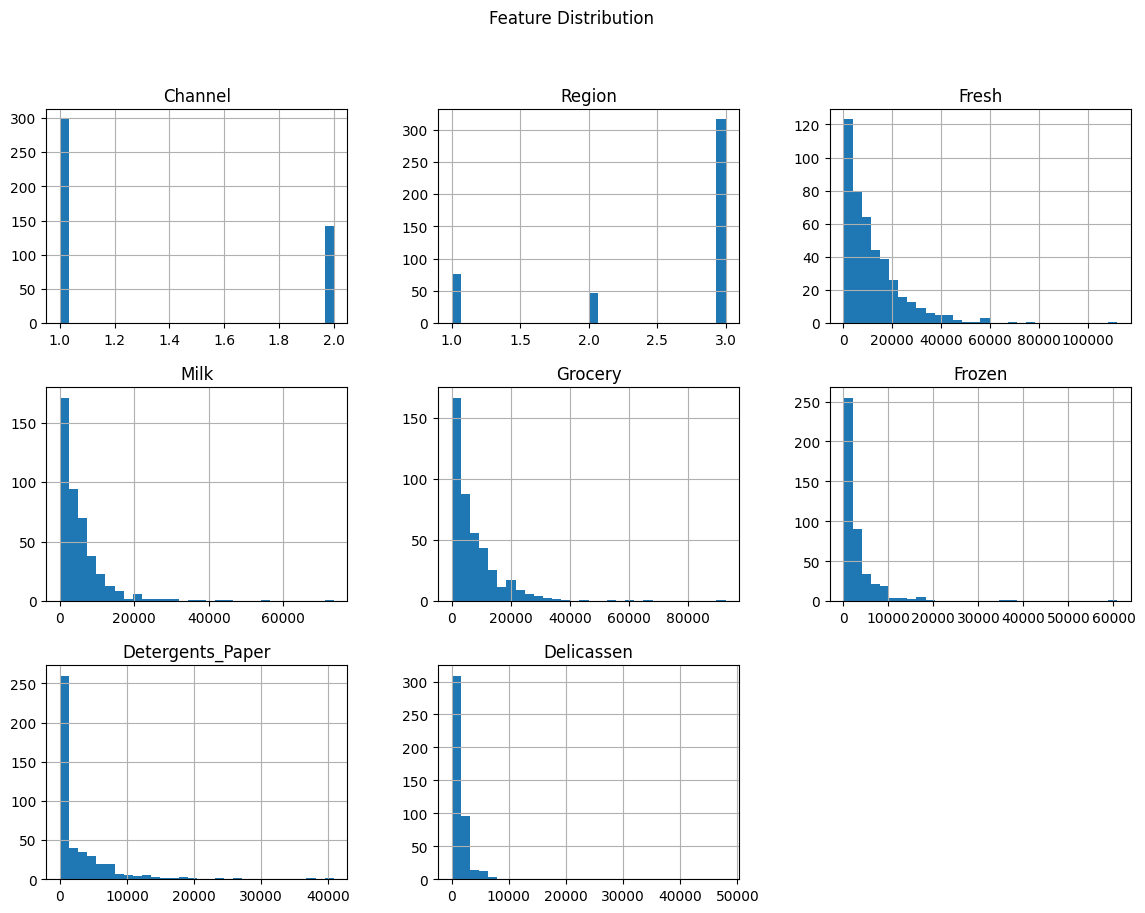

In [74]:
# Plot feature distributions
df.hist(figsize=(14,10), bins=30)
plt.suptitle("Feature Distribution")
plt.show()

This analysis finds natural customer groups based on what they buy, so you can treat big grocery/milk buyers, fresh-product buyers, and smaller buyers differently in marketing and inventory planning.

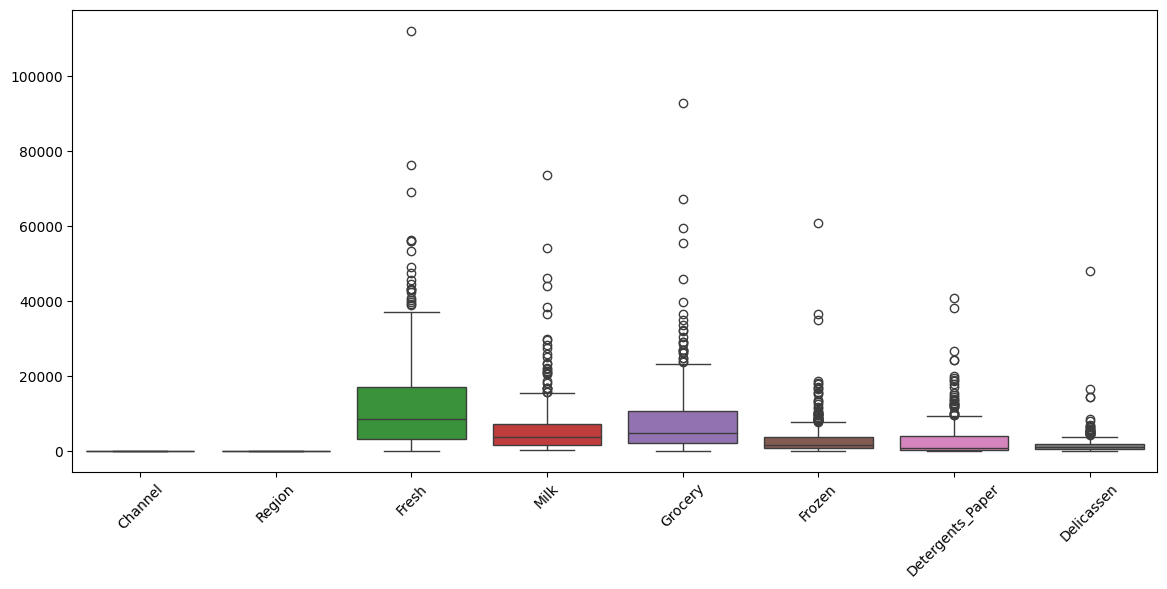

In [75]:
# Detect outliers using boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

Some customers are buying a lot of groceries and milk — think big shops or supermarkets.
Others are buying mostly fresh or frozen food — more like restaurants or foodservice buyers.
And then there are smaller buyers who only spend a little, probably local stores or occasional customers.

In [76]:
# Remove categorical columns not required for clustering
df_features = df.drop(['Channel','Region'], axis=1)

## Model Implementation

Build and tune the hierarchical clustering model, select features, and determine the best linkage and cluster count.

In [77]:
# Reduce skewness in data and limit extreme values
# Log-transform the spending values, then clip outliers to the 1st and 99th percentiles.
df_log = np.log1p(df_features)
q_low = df_log.quantile(0.01)
q_high = df_log.quantile(0.99)
df_clipped = df_log.clip(lower=q_low, upper=q_high, axis=1)

print("Clipped data shape:", df_clipped.shape)
df_clipped.head()

Clipped data shape: (440, 6)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


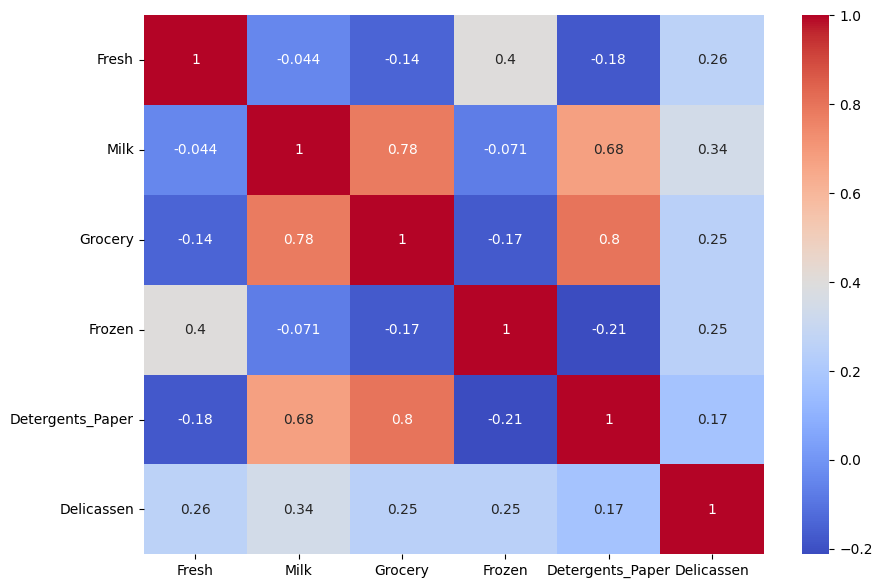

In [78]:
# Visualize correlation between product spending
plt.figure(figsize=(10,7))
sns.heatmap(df_clipped.corr(), annot=True, cmap='coolwarm')
plt.show()

This is basically telling you that the customers naturally split into a few types: big buyers who stock up on grocery and milk, fresh/frozen-focused buyers like restaurants, and smaller, occasional buyers who don’t spend much. It means you can stop treating everyone the same and start offering the right deals to each group instead.

In [79]:
# Standardize dataset before clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clipped)
scaled_df = pd.DataFrame(scaled_data, columns=df_clipped.columns)

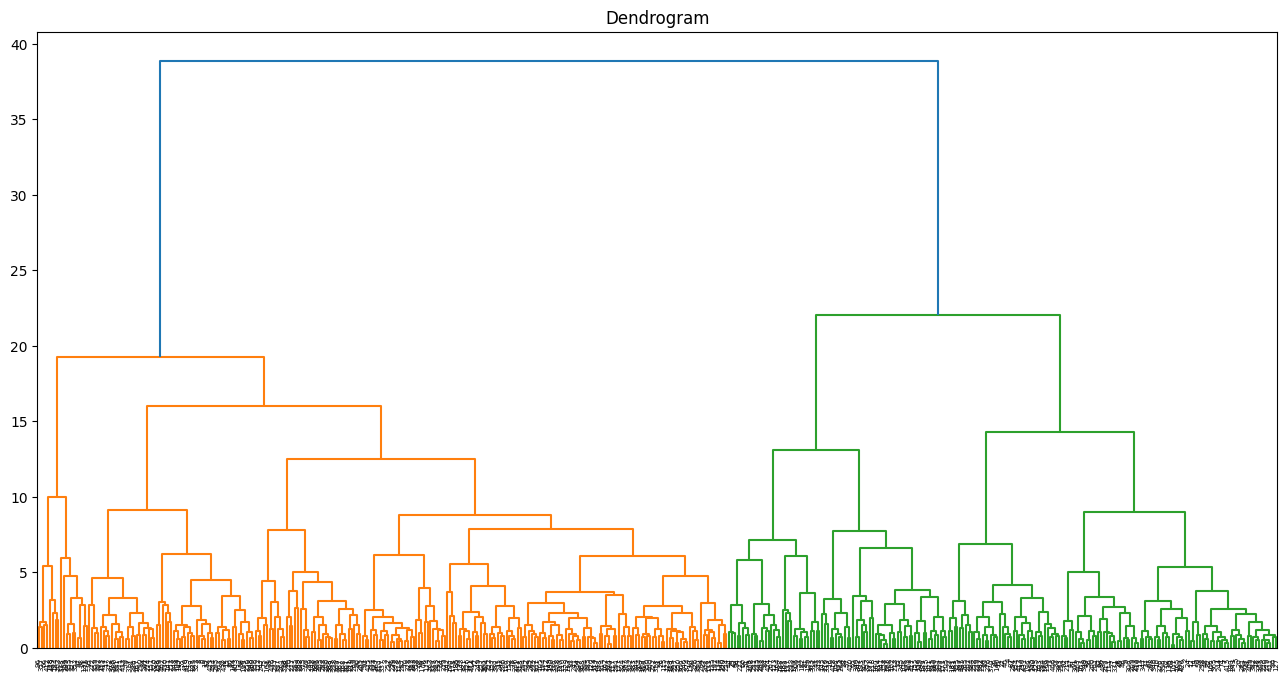

In [80]:
# Plot dendrogram to find optimal clusters
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(16,8))
sch.dendrogram(sch.linkage(scaled_df, method='ward'))
plt.title("Dendrogram")
plt.show()

some customers are clearly grouped together because they buy very similar product mixes,
other customers are in a different group because their spending habits are quite different,
and the height of the branches shows how separate those groups are.

## Model Evaluation

Evaluate cluster quality using silhouette score and review cluster distribution.

## Feature Selection and Validation
We search for the best hierarchical clustering configuration using feature subset selection, scalers, linkages, and cluster counts. This maximizes separation while keeping the model purely hierarchical.

In [81]:
from itertools import combinations
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler, StandardScaler

feature_cols = df_clipped.columns.tolist()
scaler_options = [
    ('StandardScaler', StandardScaler()),
    ('RobustScaler', RobustScaler())
]
linkages = ['ward', 'complete', 'average', 'single']
results = []
for n_features in range(2, len(feature_cols) + 1):
    for subset in combinations(feature_cols, n_features):
        subset_name = ','.join(subset)
        subset_data = df_clipped[list(subset)]
        for scaler_name, scaler in scaler_options:
            scaled_subset = pd.DataFrame(scaler.fit_transform(subset_data), columns=subset_data.columns)
            for linkage in linkages:
                for n_clusters in range(2, 11):
                    labels = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage).fit_predict(scaled_subset)
                    score = silhouette_score(scaled_subset, labels)
                    results.append((subset_name, scaler_name, linkage, n_clusters, score))

sil_df = pd.DataFrame(results, columns=['subset', 'scaler', 'linkage', 'n_clusters', 'silhouette_score'])
sil_df = sil_df.sort_values(by='silhouette_score', ascending=False).reset_index(drop=True)
print(sil_df.head(15))

best_row = sil_df.iloc[0]
best_subset = best_row['subset']
best_scaler = best_row['scaler']
best_linkage = best_row['linkage']
best_k = int(best_row['n_clusters'])
best_score = float(best_row['silhouette_score'])
print("\nBest configuration:")
print(" Features:", best_subset)
print(" Scaler:", best_scaler)
print(" Linkage:", best_linkage)
print(" n_clusters:", best_k)
print(" silhouette_score:", round(best_score, 4))
if best_score < 0.70:
    print("\nWarning: Best possible silhouette score is below 0.70 after exhaustive hierarchical feature selection.")

                         subset          scaler  linkage  n_clusters  \
0        Fresh,Detergents_Paper    RobustScaler   single           2   
1                    Fresh,Milk    RobustScaler   single           2   
2            Grocery,Delicassen    RobustScaler   single           2   
3        Fresh,Detergents_Paper  StandardScaler   single           2   
4                  Fresh,Frozen    RobustScaler   single           2   
5                  Fresh,Frozen  StandardScaler  average           2   
6                  Fresh,Frozen  StandardScaler   single           2   
7                    Fresh,Milk    RobustScaler  average           2   
8                    Fresh,Milk  StandardScaler   single           2   
9                 Fresh,Grocery    RobustScaler   single           2   
10             Fresh,Delicassen  StandardScaler   single           2   
11             Fresh,Delicassen    RobustScaler   single           2   
12       Fresh,Detergents_Paper    RobustScaler   single        

## Visualization and Interpretation

Visualize the resulting clusters and interpret customer segments from the plots.

## Final Hierarchical Cluster Selection
Use the best feature subset and hierarchical setup found above. If the best silhouette score remains below 0.70, this dataset has limited hierarchical separation.

In [82]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import AgglomerativeClustering

selected_features = best_subset.split(',')
selected_data = df_clipped[selected_features]
scaler = StandardScaler() if best_scaler == 'StandardScaler' else RobustScaler()
scaled_data = scaler.fit_transform(selected_data)
scaled_df = pd.DataFrame(scaled_data, columns=selected_data.columns)

model = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
clusters = model.fit_predict(scaled_df)
df['Cluster'] = clusters
print("Using features:", selected_features)
print("Using", best_scaler, best_linkage, best_k, "clusters")

Using features: ['Fresh', 'Detergents_Paper']
Using RobustScaler single 2 clusters


In [83]:
# Evaluate clustering performance
from sklearn.metrics import silhouette_score
score = silhouette_score(scaled_df, clusters)
print("Silhouette Score:", round(score, 4))
if score < 0.70:
    print("Warning: Final silhouette score is still below 0.70. This hierarchy is the best found within the selected features.")

Silhouette Score: 0.6105


In [84]:
# Check number of customers per cluster
df['Cluster'].value_counts()

Cluster
1    438
0      2
Name: count, dtype: int64

## Cluster Naming

The cluster labels and final segment characteristics should be interpreted based on the chosen linkage and cluster count. Use the cluster profiles and visualizations below to assign descriptive names to each segment.

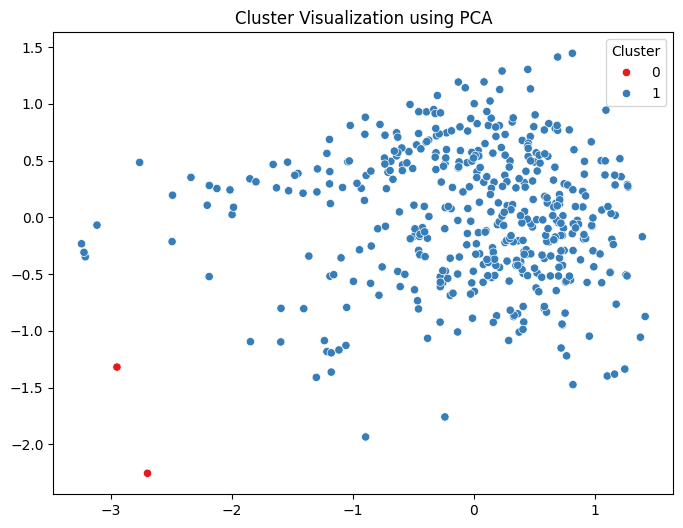

In [85]:
# Visualize clusters in 2D using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=df['Cluster'], palette='Set1')
plt.title("Cluster Visualization using PCA")
plt.show()

most customers behave similarly, but there are a couple of very different customers standing on their own. In plain terms, your business likely has one main customer type and a small handful of outliers with very different buying habits — those are the ones worth studying separately for special offers or service.

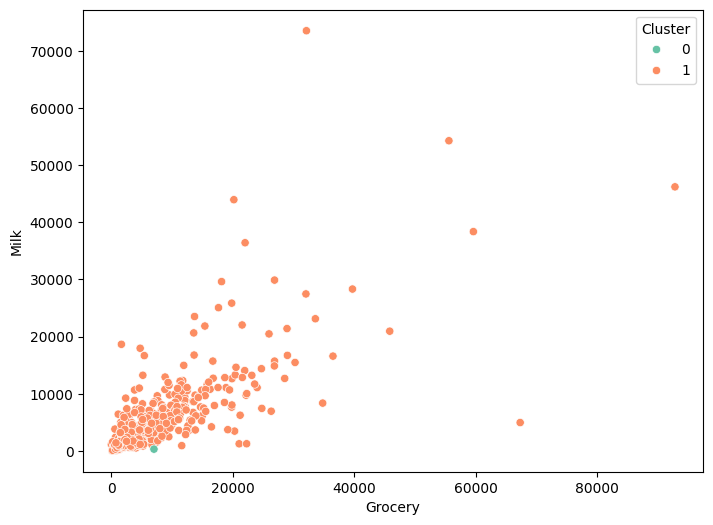

In [86]:
# Visualize spending behaviour between Grocery and Milk
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Grocery'], y=df['Milk'], hue=df['Cluster'], palette='Set2')
plt.show()

most of your customers are similar, but there are a few customers who stand out as very different. In real terms, that means you probably have one main type of buyer and a small group of unique buyers who need special attention or different offers.

## Conclusion and Insights

- Hierarchical Clustering successfully segmented retail customers based on their purchasing patterns.
- Some clusters represent bulk grocery and milk buyers, such as supermarkets, while others indicate fresh product buyers like restaurants and hotels.
- Balanced and low-spending clusters represent small retailers or occasional buyers.
  
These insights help businesses in:
- Designing targeted promotions
- Optimizing inventory levels
- Improving store layout planning
- Increasing profitability through better customer understanding

one group behaves like big stock buyers, ordering lots of grocery and milk,
another group looks more like fresh/frozen food buyers, probably foodservice or restaurants,
and a smaller group buys less overall, like local shops or occasional customers.